<a href="https://colab.research.google.com/github/tanishjain-tmj/Data-profiler-Customer-churn-Data/blob/main/DataProfiler_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Profiler project:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Part B : Data acquisition:
#csv
df= pd.read_csv("/content/ecommerce_customer_data.csv")
df.head()

,customer_id,name,email,age,gender,annual_income,total_purchases,avg_purchase_value,days_since_last_purchase,customer_satisfaction,churn
0,a3071abd-8922-4608-95af-676364cb411d,Erica Powers,houseariana@example.net,56,Male,41672,11,170.75,14,5,0
1,114a0236-61b3-4447-964c-dbe6ac3d0773,Sarah Jones,ufranklin@example.org,46,Female,78217,9,63.17,8,4,0
2,c2fcf312-df91-400a-ab0e-822c1fab051a,Jaime Peterson,james10@example.com,32,Female,28279,10,55.09,8,2,0
3,7885497e-eb68-4c32-b4a3-b110d6af8aae,Rebecca Wolfe,pricedustin@example.org,60,Female,17017,15,110.88,18,4,0
4,b212448f-04ae-4943-a90e-0c8500b486fc,Kenneth Peterson,qwyatt@example.net,25,Male,56600,10,158.37,42,3,1


In [3]:
#json
df_json= pd.read_json("/content/customer_extra.json")
df_json.head()

,customer_id,membership_type,preferred_category
0,1,Premium,Electronics
1,2,Basic,Clothing
2,3,Premium,Beauty
3,4,Standard,Home
4,5,Basic,Sports


In [4]:
#sql
import sqlite3
import pandas as pd

conn=sqlite3.connect("customer_extra.db")
query= "Select* from customer_activity"
df_sql= pd.read_sql(query,conn)
df_sql.head()
conn.close()

In [5]:
#api
import requests
import pandas as pd

url = "https://dummyjson.com/products?limit=10"

response = requests.get(url)
print("Status Code:", response.status_code)
if response.status_code == 200:
    data = response.json()
    products = data["products"]
    df_api = pd.DataFrame(products)
    print(df_api.head())
else:
    print("Failed to fetch data from API")


Status Code: 200
   id                          title  \
0   1  Essence Mascara Lash Princess   
1   2  Eyeshadow Palette with Mirror   
2   3                Powder Canister   
3   4                   Red Lipstick   
4   5                Red Nail Polish   

                                         description category  price  \
0  The Essence Mascara Lash Princess is a popular...   beauty   9.99   
1  The Eyeshadow Palette with Mirror offers a ver...   beauty  19.99   
2  The Powder Canister is a finely milled setting...   beauty  14.99   
3  The Red Lipstick is a classic and bold choice ...   beauty  12.99   
4  The Red Nail Polish offers a rich and glossy r...   beauty   8.99   

   discountPercentage  rating  stock                   tags           brand  \
0               10.48    2.56     99      [beauty, mascara]         Essence   
1               18.19    2.86     34    [beauty, eyeshadow]  Glamour Beauty   
2                9.84    4.64     89  [beauty, face powder]    Velvet To

In [6]:
#part c: data understanding and cleaning :
#treating csv dataa as are main dataset
df.head()

,customer_id,name,email,age,gender,annual_income,total_purchases,avg_purchase_value,days_since_last_purchase,customer_satisfaction,churn
0,a3071abd-8922-4608-95af-676364cb411d,Erica Powers,houseariana@example.net,56,Male,41672,11,170.75,14,5,0
1,114a0236-61b3-4447-964c-dbe6ac3d0773,Sarah Jones,ufranklin@example.org,46,Female,78217,9,63.17,8,4,0
2,c2fcf312-df91-400a-ab0e-822c1fab051a,Jaime Peterson,james10@example.com,32,Female,28279,10,55.09,8,2,0
3,7885497e-eb68-4c32-b4a3-b110d6af8aae,Rebecca Wolfe,pricedustin@example.org,60,Female,17017,15,110.88,18,4,0
4,b212448f-04ae-4943-a90e-0c8500b486fc,Kenneth Peterson,qwyatt@example.net,25,Male,56600,10,158.37,42,3,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1000 non-null   object 
 1   name                      1000 non-null   object 
 2   email                     1000 non-null   object 
 3   age                       1000 non-null   int64  
 4   gender                    1000 non-null   object 
 5   annual_income             1000 non-null   int64  
 6   total_purchases           1000 non-null   int64  
 7   avg_purchase_value        1000 non-null   float64
 8   days_since_last_purchase  1000 non-null   int64  
 9   customer_satisfaction     1000 non-null   int64  
 10  churn                     1000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 86.1+ KB


In [8]:
df.describe()

,age,annual_income,total_purchases,avg_purchase_value,days_since_last_purchase,customer_satisfaction,churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,50852.235000,9.967000,109.875260,28.824000,2.947000,0.310000
std,13.497852,15009.184041,3.153388,52.173485,29.470961,1.453377,0.462725
min,18.000000,6179.000000,2.000000,21.110000,0.000000,1.000000,0.000000
25%,29.000000,40770.250000,8.000000,64.660000,8.000000,2.000000,0.000000
50%,42.000000,50631.000000,10.000000,108.465000,19.000000,3.000000,0.000000
75%,52.000000,60796.750000,12.000000,155.690000,42.000000,4.000000,1.000000
max,64.000000,97896.000000,21.000000,199.880000,225.000000,5.000000,1.000000


In [9]:
# annual-income and total-pur, dayssincelastpurchase have outliers

In [10]:
df.drop_duplicates()

,customer_id,name,email,age,gender,annual_income,total_purchases,avg_purchase_value,days_since_last_purchase,customer_satisfaction,churn
0,a3071abd-8922-4608-95af-676364cb411d,Erica Powers,houseariana@example.net,56,Male,41672,11,170.75,14,5,0
1,114a0236-61b3-4447-964c-dbe6ac3d0773,Sarah Jones,ufranklin@example.org,46,Female,78217,9,63.17,8,4,0
2,c2fcf312-df91-400a-ab0e-822c1fab051a,Jaime Peterson,james10@example.com,32,Female,28279,10,55.09,8,2,0
3,7885497e-eb68-4c32-b4a3-b110d6af8aae,Rebecca Wolfe,pricedustin@example.org,60,Female,17017,15,110.88,18,4,0
4,b212448f-04ae-4943-a90e-0c8500b486fc,Kenneth Peterson,qwyatt@example.net,25,Male,56600,10,158.37,42,3,1
...,...,...,...,...,...,...,...,...,...,...,...
995,993b714d-401b-49b7-acb5-012405812705,David Garcia,ronaldparker@example.net,22,Male,36209,10,117.94,30,3,0
996,28baa956-01c4-4a35-963e-cd3dc47ba6d2,Robert Nelson,mary75@example.com,40,Male,12045,10,119.31,24,2,0
997,75c38180-3083-4e5d-a0bb-2617d2414f31,William Walker,kevin12@example.net,27,Female,45709,11,84.18,40,2,0
998,4c978c03-0bd6-44b9-b3ea-ecd3b3e8fc5f,Hannah Mccoy,snyderdavid@example.net,61,Male,66514,10,100.51,12,5,1


In [11]:
#removing outlier
Q1 = df.select_dtypes(include='number').quantile(0.25)
Q3 = df.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        (df.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) |
        (df.select_dtypes(include='number') > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 949 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               949 non-null    object 
 1   name                      949 non-null    object 
 2   email                     949 non-null    object 
 3   age                       949 non-null    int64  
 4   gender                    949 non-null    object 
 5   annual_income             949 non-null    int64  
 6   total_purchases           949 non-null    int64  
 7   avg_purchase_value        949 non-null    float64
 8   days_since_last_purchase  949 non-null    int64  
 9   customer_satisfaction     949 non-null    int64  
 10  churn                     949 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 89.0+ KB


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,949.0,41.047418,13.475829,18.00,29.00,42.00,52.00,64.00
annual_income,949.0,51068.879874,14737.649146,11134.00,40823.00,50608.00,61023.00,89025.00
total_purchases,949.0,9.861960,3.028507,3.00,8.00,10.00,12.00,18.00
avg_purchase_value,949.0,110.132234,51.898624,21.11,66.29,108.74,155.63,199.88
days_since_last_purchase,949.0,25.489989,22.711573,0.00,8.00,19.00,38.00,93.00
customer_satisfaction,949.0,2.942044,1.454591,1.00,2.00,3.00,4.00,5.00
churn,949.0,0.306639,0.461341,0.00,0.00,0.00,1.00,1.00


In [14]:
df['gender'].value_counts()

,count
gender,
Male,499
Female,450


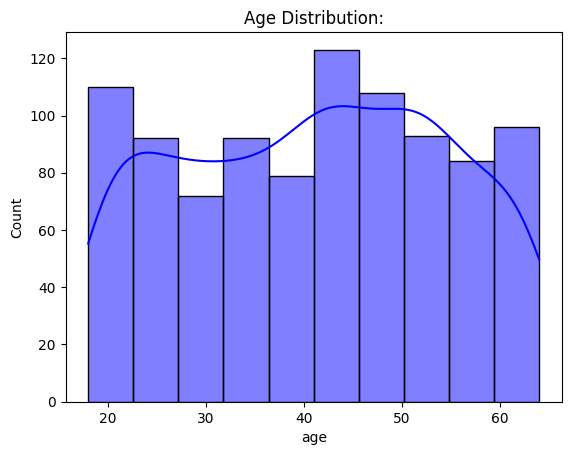

In [18]:
#part D : EDA
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'],bins=10,kde=True,color="blue")
plt.title("Age Distribution:")
plt.show()

insights:
the age distribution is completely spread over all age groups , higher customers are of 40-50 age group, and less customers are of 30-40 age group.

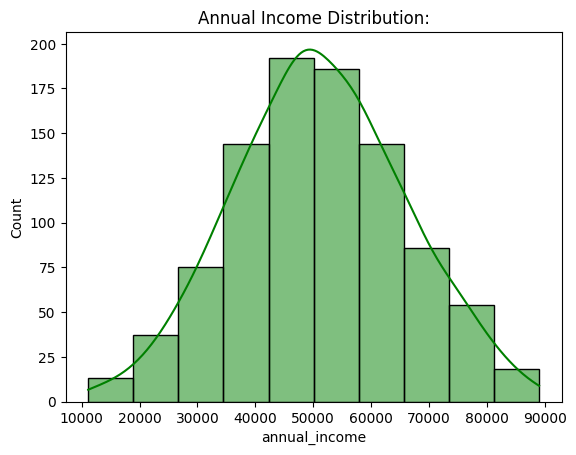

In [21]:
sns.histplot(df['annual_income'],bins=10,kde=True,color="green")
plt.title("Annual Income Distribution:")
plt.show()

insights:
the annual income distribution forms are perfect normal form , higher customers are of the range 40k-60k income .

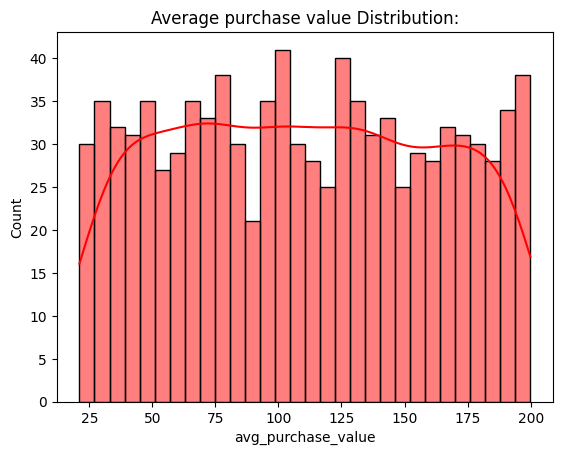

In [24]:
sns.histplot(df['avg_purchase_value'],bins=30,kde=True,color="red")
plt.title("Average purchase value Distribution:")
plt.show()

insights:
The avg purchase value is too much spread out , means products of all price ranges have a likely equal sales ,but among all 100 rupee value is the of most count saled product.

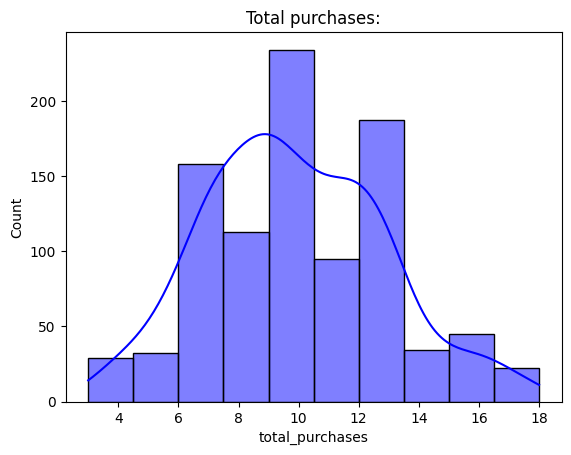

In [25]:
sns.histplot(df['total_purchases'],bins=10,kde=True,color="blue")
plt.title("Total purchases:")
plt.show()

insights: maximum customers have total purchases of 8-12 orders.

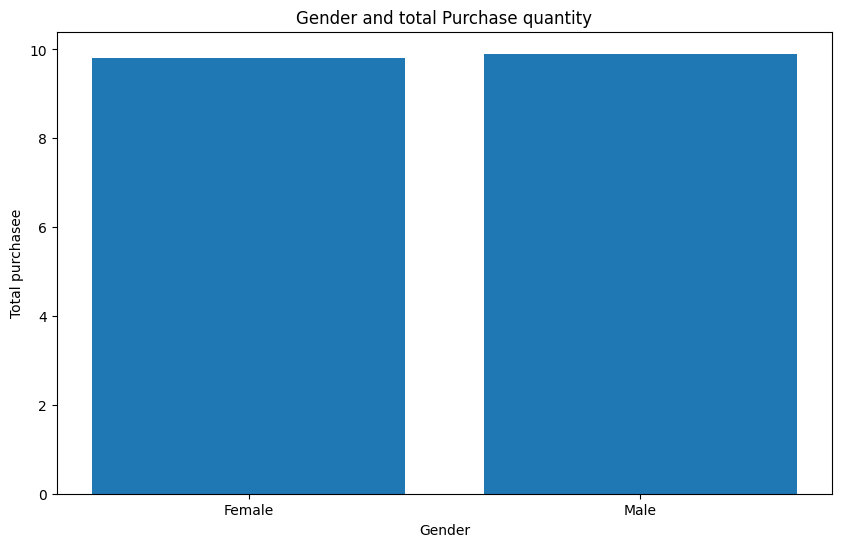

In [33]:
df1=df.groupby('gender')['total_purchases'].mean()
plt.figure(figsize=(10,6))
plt.bar(df1.index,df1.values)
plt.xlabel("Gender")
plt.ylabel("Total purchasee")
plt.title("Gender and total Purchase quantity")
plt.show()

insights:
seems like both male, female on avg have same no of purchases

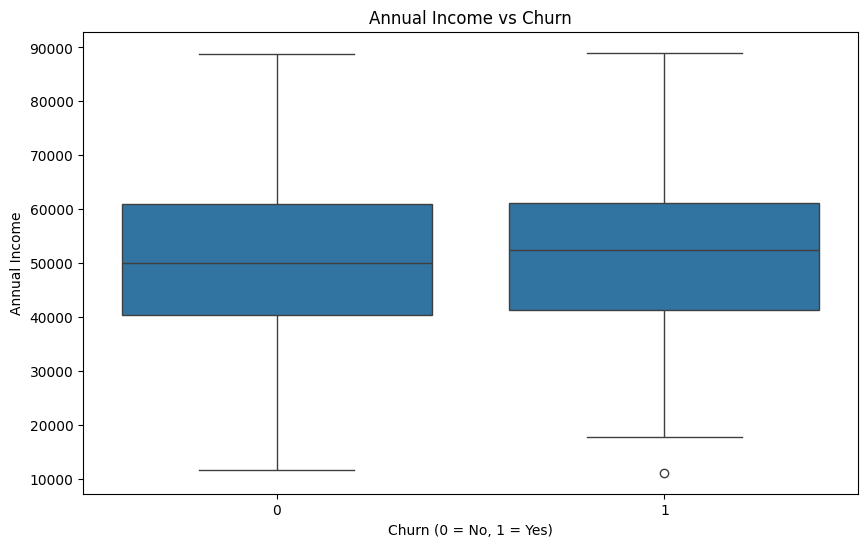

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='annual_income', data=df)
plt.title("Annual Income vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Annual Income")
plt.show()

insights:
income is not the main reason of customer churn.

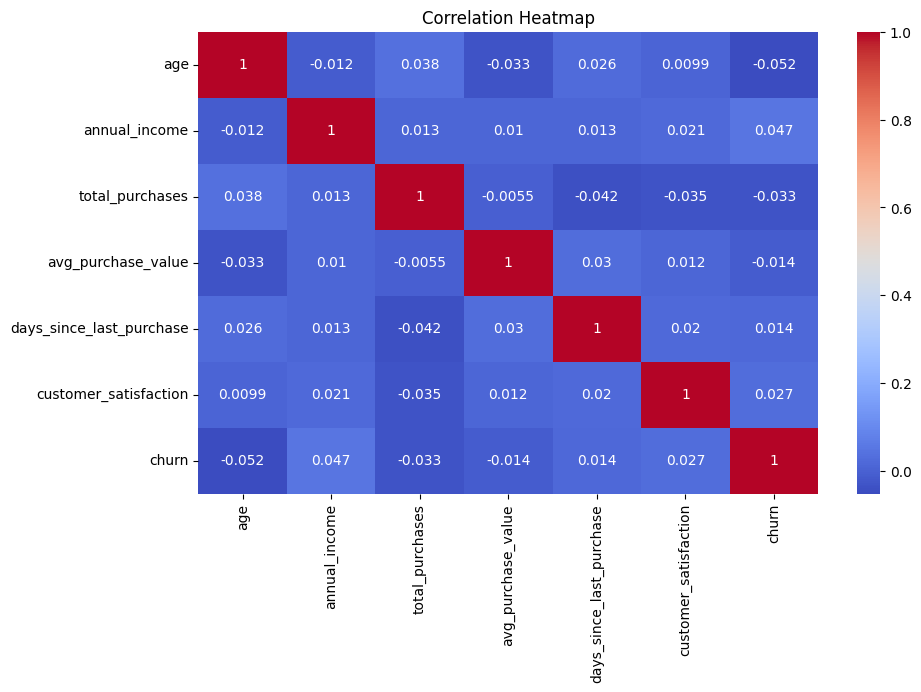

In [42]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

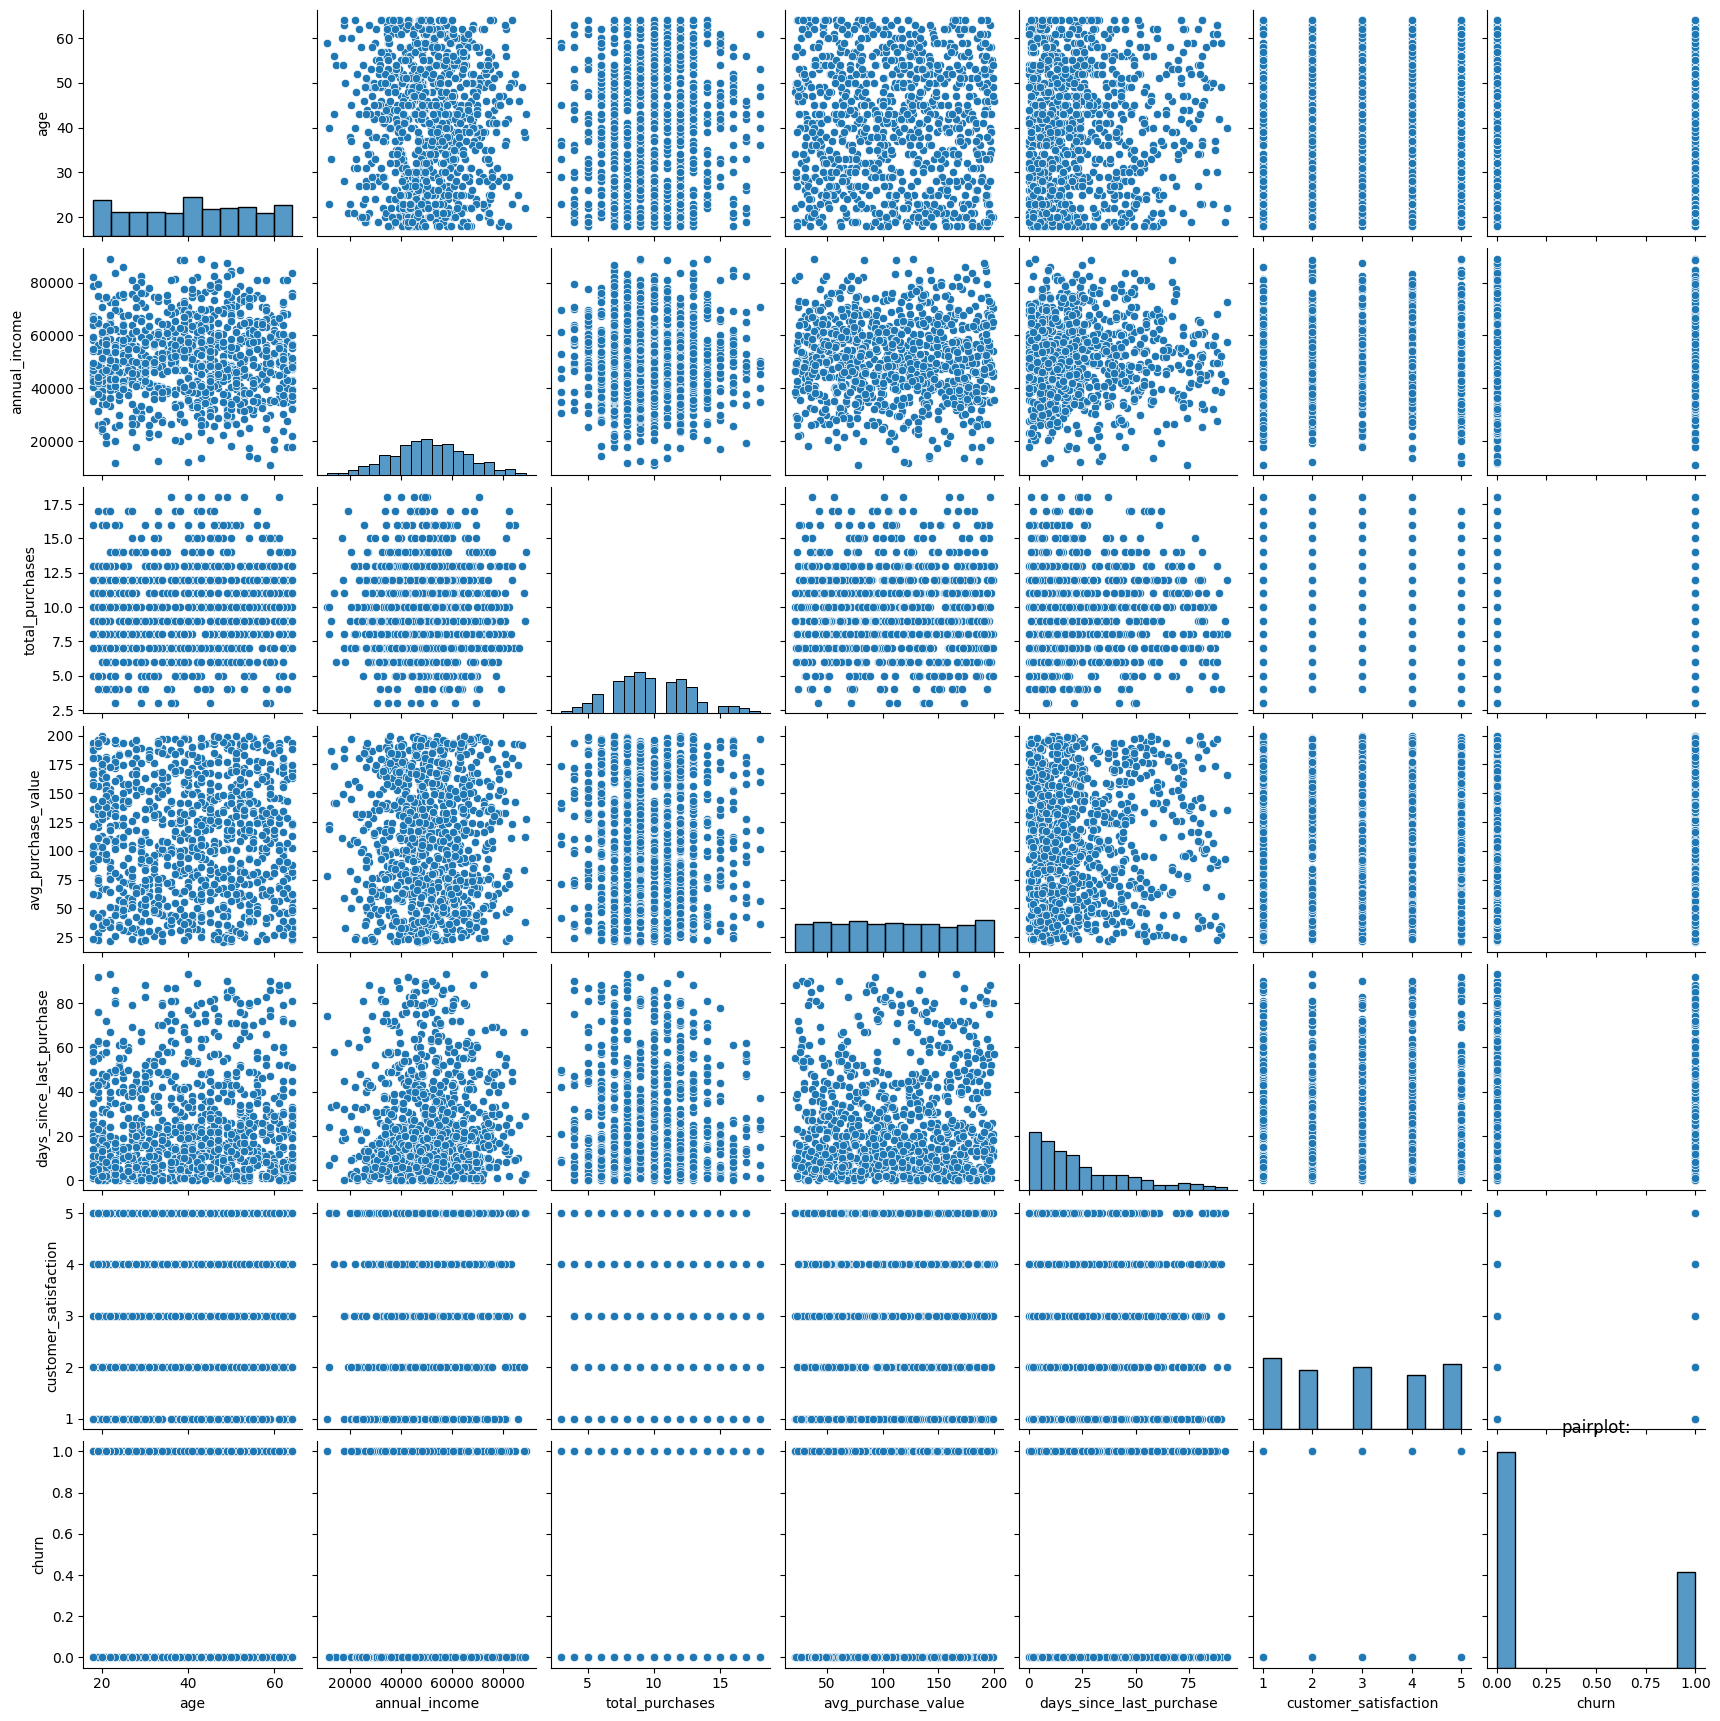

In [43]:
sns.pairplot(df)
plt.title("pairplot:")
plt.show()

In [47]:
#part E:data profiling
from ydata_profiling import ProfileReport

profile=ProfileReport(df, title="Customer churn data profiling report", explorative=True)
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 47.40it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]